결과 저장 파일 구조 

In [1]:
import pandas as pd

df = pd.read_csv(
    "/Users/rnlghdb/NDL/data/LSUM_result/Flna29_gr25uw_1_Subt2__0__81198_LSUM.csv"
)

print(df.shape)
print(df.columns)
df.head()

(1177, 5)
Index(['Coeff_of_GCaMP', 'Coeff_of_jRGECO', 'Intercept',
       'Ratio_of_GCaMP_to_jRGECO', 'R_Squared'],
      dtype='object')


,Coeff_of_GCaMP,Coeff_of_jRGECO,Intercept,Ratio_of_GCaMP_to_jRGECO,R_Squared
0,875.085706,786.476269,-8.479467,1.112666,0.999516
1,881.679815,782.407888,-14.090519,1.126880,0.999490
2,871.427943,786.947841,-6.795741,1.107352,0.999426
3,872.404568,786.160820,-4.941138,1.109702,0.999540
4,879.022258,784.033575,-8.841292,1.121154,0.999419


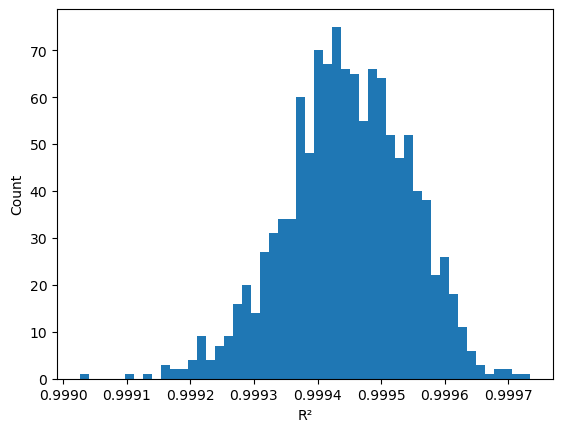

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.hist(df["R_Squared"], bins=50)
plt.xlabel("R²")
plt.ylabel("Count")
plt.show()

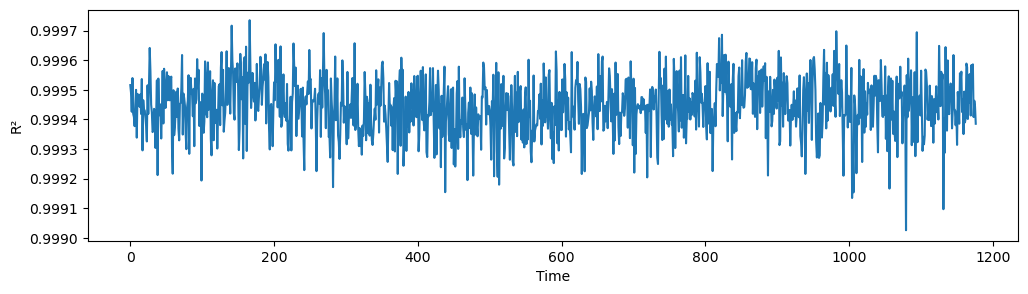

In [5]:
plt.figure(figsize=(12,3))

plt.plot(df["R_Squared"])

plt.ylabel("R²")

plt.xlabel("Time")

plt.show()

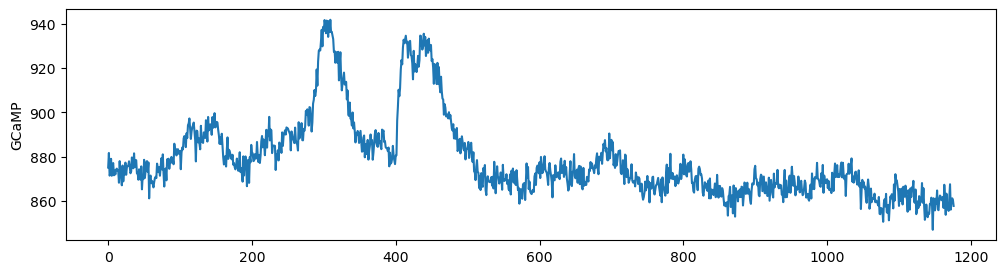

In [6]:
plt.figure(figsize=(12,3))

plt.plot(df["Coeff_of_GCaMP"])

plt.ylabel("GCaMP")

plt.show()

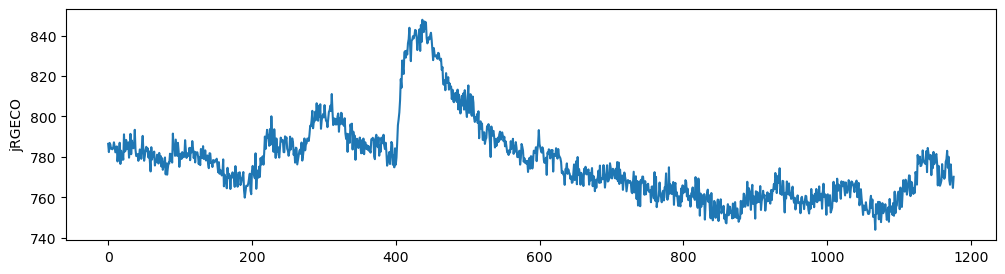

In [7]:
plt.figure(figsize=(12,3))

plt.plot(df["Coeff_of_jRGECO"])

plt.ylabel("jRGECO")

plt.show()

In [8]:
from scipy.stats import zscore

df["GCaMP_z"] = zscore(df["Coeff_of_GCaMP"])
df["jRGECO_z"] = zscore(df["Coeff_of_jRGECO"])

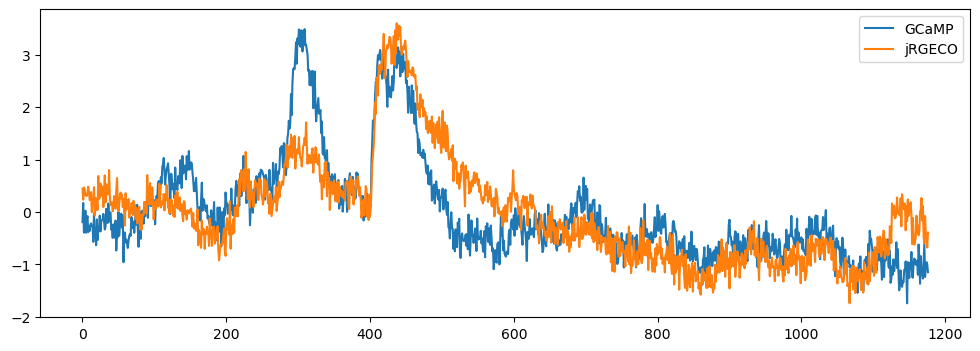

In [9]:
plt.figure(figsize=(12,4))

plt.plot(df["GCaMP_z"], label="GCaMP")
plt.plot(df["jRGECO_z"], label="jRGECO")

plt.legend()
plt.show()

In [10]:
df[["GCaMP_z","jRGECO_z"]].head()

,GCaMP_z,jRGECO_z
0,-0.191471,0.444164
1,0.171646,0.234829
2,-0.392893,0.468428
3,-0.339113,0.427933
4,0.025303,0.318477


In [11]:
print(df.columns)

Index(['Coeff_of_GCaMP', 'Coeff_of_jRGECO', 'Intercept',
       'Ratio_of_GCaMP_to_jRGECO', 'R_Squared', 'GCaMP_z', 'jRGECO_z'],
      dtype='object')


In [12]:
from scipy.stats import pearsonr

r, p = pearsonr(
    df["GCaMP_z"],
    df["jRGECO_z"]
)

print("r =", r)
print("p =", p)

r = 0.7754563699374178
p = 6.852342053618224e-237


Pearson r = 0.775\
p = 6.85 × 10^-237\
GCaMP와 jRGECO가 상당히 강한 양의 상관관계

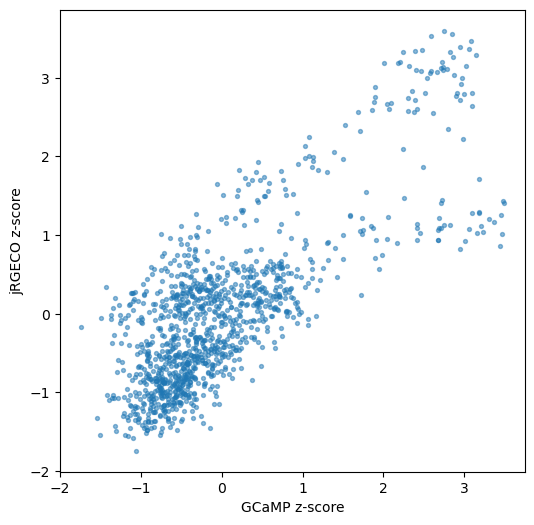

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(

    df["GCaMP_z"],

    df["jRGECO_z"],

    s=8,

    alpha=0.5

)

plt.xlabel("GCaMP z-score")

plt.ylabel("jRGECO z-score")

plt.show()

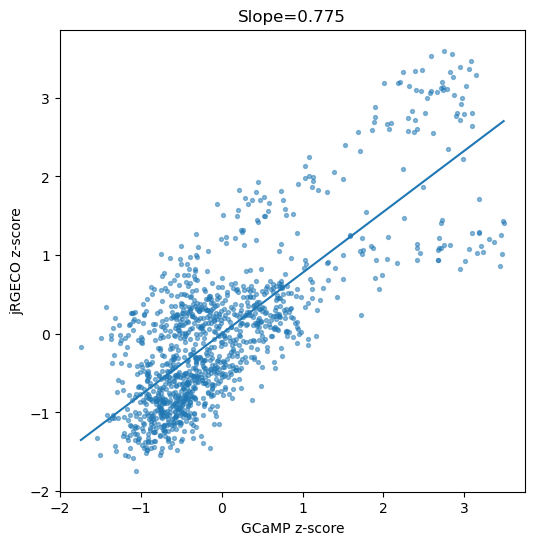

In [14]:
import numpy as np

x = df["GCaMP_z"]

y = df["jRGECO_z"]

coef = np.polyfit(x, y, 1)

xx = np.linspace(x.min(), x.max(), 100)

plt.figure(figsize=(6,6))

plt.scatter(x, y, s=8, alpha=0.5)

plt.plot(xx, np.polyval(coef, xx))

plt.xlabel("GCaMP z-score")

plt.ylabel("jRGECO z-score")

plt.title(f"Slope={coef[0]:.3f}")

plt.show()

회귀선 기울기 0.775\
GCaMP가 1 SD 증가할 때 -> jRGECO는 평균적으로 0.775 SD 증가하는 경향

In [15]:
output_path = "/Users/rnlghdb/NDL/data/LSUM_result/Flna29_gr25uw_1_Subt2__0__81198_LSUM_z.csv"

df.to_csv(output_path, index=False)

print(f"저장 완료: {output_path}")
print(df.columns)
print(df.shape)

저장 완료: /Users/rnlghdb/NDL/data/LSUM_result/Flna29_gr25uw_1_Subt2__0__81198_LSUM_z.csv
Index(['Coeff_of_GCaMP', 'Coeff_of_jRGECO', 'Intercept',
       'Ratio_of_GCaMP_to_jRGECO', 'R_Squared', 'GCaMP_z', 'jRGECO_z'],
      dtype='object')
(1177, 7)


In [17]:
check = pd.read_csv(output_path)

check.columns

Index(['Coeff_of_GCaMP', 'Coeff_of_jRGECO', 'Intercept',
       'Ratio_of_GCaMP_to_jRGECO', 'R_Squared', 'GCaMP_z', 'jRGECO_z'],
      dtype='object')

In [18]:
check.head()

,Coeff_of_GCaMP,Coeff_of_jRGECO,Intercept,Ratio_of_GCaMP_to_jRGECO,R_Squared,GCaMP_z,jRGECO_z
0,875.085706,786.476269,-8.479467,1.112666,0.999516,-0.191471,0.444164
1,881.679815,782.407888,-14.090519,1.126880,0.999490,0.171646,0.234829
2,871.427943,786.947841,-6.795741,1.107352,0.999426,-0.392893,0.468428
3,872.404568,786.160820,-4.941138,1.109702,0.999540,-0.339113,0.427933
4,879.022258,784.033575,-8.841292,1.121154,0.999419,0.025303,0.318477


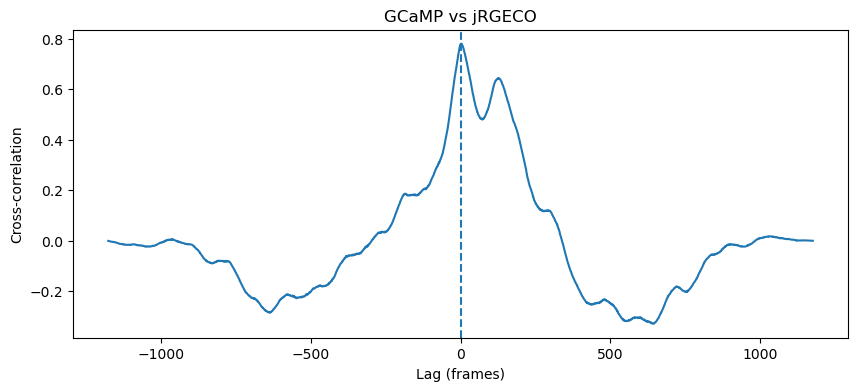

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

x = df["GCaMP_z"].values
y = df["jRGECO_z"].values

# 평균 제거
x = x - np.mean(x)
y = y - np.mean(y)

corr = correlate(y, x, mode="full")

lags = np.arange(-len(x)+1, len(x))

# 정규화
corr = corr / (np.std(x) * np.std(y) * len(x))

plt.figure(figsize=(10,4))
plt.plot(lags, corr)

plt.axvline(0, linestyle="--")

plt.xlabel("Lag (frames)")
plt.ylabel("Cross-correlation")
plt.title("GCaMP vs jRGECO")
plt.show()

lag = 0 : GCaMP와 jRGECO가 거의 동시에 움직임\
lag = +20 : GCaMP 변화 후 20 frame 뒤에 jRGECO 변화\
lag = -20 : jRGECO가 먼저 GCaMP가 나중